In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


In [73]:
# Load the phenotype data
catalog_data = pd.read_csv('./data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv')

In [74]:
catalog_data.shape

(4677, 15)

In [75]:
catalog_data = catalog_data.drop_duplicates()

In [76]:
print(catalog_data.shape)

(4677, 15)


In [77]:
catalog_data['confidence'].value_counts()

confidence
3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: count, dtype: int64

In [78]:
catalog_data.columns

Index(['gene', 'thermostability', 'Wildtype_AA', 'position', 'Mutated_AA',
       'one_letter_mutation', 'drug', 'confidence', 'delta_z', 'frequency',
       'phenotype', 'Proximity_to_R_Conferring', 'Nearest_Mutation_Index',
       'aa_index_dist', 'llr_score'],
      dtype='object')

In [79]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)


gene
Rv0678    0
atpE      0
ddn       0
embB      0
ethA      0
fgd1      0
gid       0
gyrA      0
gyrB      0
inhA      0
katG      0
pepQ      0
pncA      0
rplC      0
rpoB      0
rpsL      0
tlyA      0
Name: llr_score, dtype: int64


In [80]:
# Filter out category 3 entries
label_data = catalog_data[catalog_data['confidence'] != "3) Uncertain significance"]


In [81]:
np.unique(label_data['confidence'].value_counts())

array([ 21,  38, 155, 160])

In [11]:
# # Specify the gene of interest
# gene_of_interest = 'rpoB'  # Replace with the gene you're interested in

# # Filter the DataFrame for the specific gene
# gene_data = catalog_data[catalog_data['gene'] == gene_of_interest]

# # Finding the index of the maximum delta_z within the filtered gene data
# max_delta_z_index = gene_data['delta_z'].idxmax()

# # Finding the index of the maximum llr_score within the filtered gene data
# max_llr_index = gene_data['llr_score'].idxmax()

# # Printing the row with the maximum delta_z for the specified gene
# print(f"Row with the highest delta_z for {gene_of_interest}:")
# print(catalog_data.loc[max_delta_z_index])

# # Printing the row with the maximum llr_score for the specified gene
# print(f"\nRow with the highest llr_score for {gene_of_interest}:")
# print(catalog_data.loc[max_llr_index])


In [82]:

# List of numeric columns to use as features
# numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score']

# numeric_columns = ['frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']
numeric_columns = ['Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

# Fill NaN values in the features with 0 or any suitable value
label_data[numeric_columns] = label_data[numeric_columns].fillna(0)

/tmp/ipykernel_3324983/655669945.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


In [83]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']

In [84]:
print(X_label.shape, y_label.shape)

(374, 4) (374,)


In [85]:
np.unique(y_label)

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '4) Not assoc w R - Interim', '5) Not assoc w R'], dtype=object)

In [86]:
# Convert the target variable to numeric labels
# y_train = y_train.map({
#     "1) Assoc w R": 1,
#     "2) Assoc w R - Interim": 2,
#     "4) Not assoc w R - Interim": 4,
#     "5) Not assoc w R": 5
# })


y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 2,
    "5) Not assoc w R": 2
})


In [87]:
y_label.value_counts()

confidence
1    315
2     59
Name: count, dtype: int64

In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

In [89]:
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)


In [90]:
X_test_split.shape

(113, 4)

In [91]:
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)


#### experimenting with random forest params

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid you want to experiment with
param_grid = {
    'n_estimators': [100, 200, 500],  # Number of trees
    'max_depth': [None, 10, 20],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples at leaf node
    'max_features': ['auto', 'sqrt', 'log2']  # Number of features to consider for the best split
}

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the metrics you want to track (you can add more as needed)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted')
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    scoring=scoring,  # Evaluate on multiple metrics
    refit='accuracy',  # Refit the model based on the accuracy score
    cv=3,  # 3-fold cross-validation
    verbose=2,  # Increase verbosity to see detailed logs
    return_train_score=True  # Return training score as well
)

# Fit the GridSearchCV on your training data
grid_search.fit(X_train_split, y_train_split)

# Collect the results
grid_results = grid_search.cv_results_

# Convert results to DataFrame for easy analysis
import pandas as pd
results_df = pd.DataFrame(grid_results)

# Save the results to a CSV file
results_df.to_csv('2021_rf_grid_search_results.csv', index=False)

# Print the best score and parameters
print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")


In [ ]:
grid_search.best_params_

In [ ]:
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)


# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))


### model evaluation

In [92]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))

Confusion Matrix:
[[92  0]
 [ 6 15]]

Classification Report:
              precision    recall  f1-score   support

           1       0.94      1.00      0.97        92
           2       1.00      0.71      0.83        21

    accuracy                           0.95       113
   macro avg       0.97      0.86      0.90       113
weighted avg       0.95      0.95      0.94       113


Accuracy Score:
0.9469026548672567


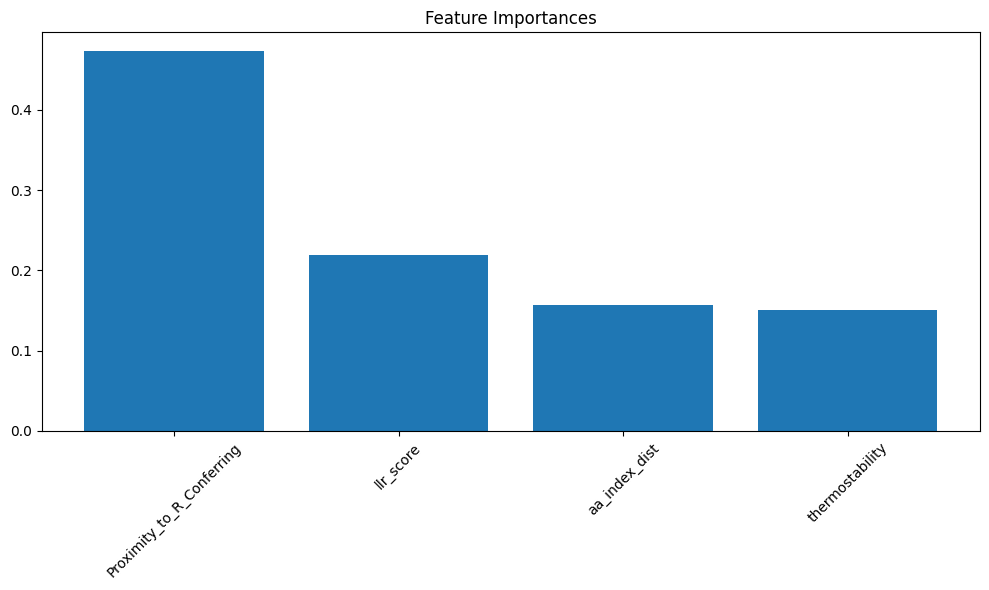

In [93]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_label.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_label.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

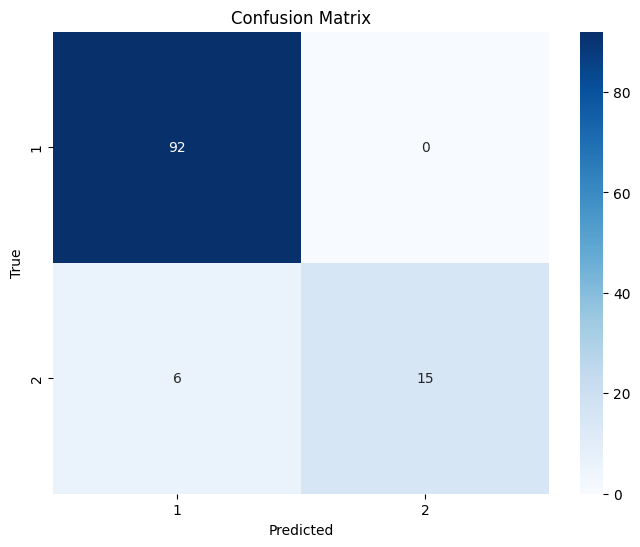

In [94]:
# # Confusion Matrix Visualization
# cm = confusion_matrix(y_test_split, y_pred_split)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [95]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}



In [96]:
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])


Unique classes: [1, 2]
Number of prediction columns in y_prob_split: 2


In [97]:
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    

# This approach ensures you are accessing the correct column for each class


In [98]:
for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

1 0.9133022774327122
2 0.9133022774327123


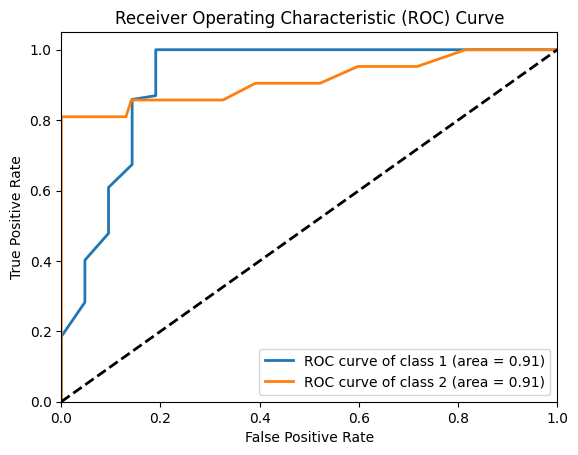

In [99]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [100]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
catalog_data.loc[catalog_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

# # Save the updated phenotype data with predictions
# phenotype_data.to_csv('/path/to/updated_phenotype_data.csv', index=False)

# print("Predictions for category 3 data have been saved to 'updated_phenotype_data.csv'.")

/tmp/ipykernel_3324983/3953226937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3324983/3953226937.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data['predicted_confidence'] = rf_classifier.

In [101]:
total_category_3_instances = len(category_3_data)
print(f"Total number of category 3 instances: {total_category_3_instances}")

Total number of category 3 instances: 4303


In [102]:
catalog_data['predicted_confidence'].value_counts()

predicted_confidence
2.0    3779
1.0     524
Name: count, dtype: int64

from IPython.display import display## find the difference between 2023 and 2021 data

In [35]:
from IPython.display import display

In [103]:
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = "./data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv"
file_2023 = "./data/derived_features/all_proteins_freq_details_proximity_aaindex_thermostability.csv"

df_2021 = pd.read_csv(file_2021)
df_2023 = pd.read_csv(file_2023)

# Merge the two datasets on gene, Wildtype_AA, position, Mutated_AA
merged_df = pd.merge(
    df_2021,
    df_2023,
    on=['gene', 'one_letter_mutation'],
    suffixes=('_2021', '_2023')
)
merged_df=merged_df.drop_duplicates()



In [104]:
# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optionally, preview the unchanged rows
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])


Number of positions where confidence remained unchanged in category 3: 5164


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
1,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
2,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
3,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
4,Rv0678,S2R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
5693,tlyA,R244P,3) Uncertain significance,3) Uncertain significance
5694,tlyA,A250T,3) Uncertain significance,3) Uncertain significance
5695,tlyA,R249Q,3) Uncertain significance,3) Uncertain significance
5696,tlyA,S252L,3) Uncertain significance,3) Uncertain significance


In [105]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]


In [106]:
print(merged_df.shape,filtered_df.shape,updated_confidence.shape)

(5698, 28) (534, 28) (169, 28)


In [107]:
filtered_df=filtered_df.drop_duplicates()

In [108]:
filtered_df['confidence_2021'].value_counts()

confidence_2021
1) Assoc w R                  170
2) Assoc w R - Interim        169
3) Uncertain significance     111
5) Not assoc w R               59
4) Not assoc w R - Interim     25
Name: count, dtype: int64

In [109]:
filtered_df['confidence_2023'].value_counts()

confidence_2023
2) Assoc w R - Interim        220
1) Assoc w R                  207
5) Not assoc w R               65
4) Not assoc w R - Interim     25
3) Uncertain significance      17
Name: count, dtype: int64

In [110]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)


Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, thermostability_2021, Wildtype_AA_2021, position_2021, Mutated_AA_2021, one_letter_mutation, drug_2021, confidence_2021, delta_z_2021, frequency_2021, phenotype_2021, Proximity_to_R_Conferring_2021, Nearest_Mutation_Index_2021, aa_index_dist_2021, llr_score_2021, thermostability_2023, Wildtype_AA_2023, position_2023, Mutated_AA_2023, drug_2023, confidence_2023, delta_z_2023, frequency_2023, phenotype_2023, Proximity_to_R_Conferring_2023, Nearest_Mutation_Index_2023, aa_index_dist_2023, llr_score_2023]
Index: []

[0 rows x 28 columns]


In [111]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)

Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 81
Value counts of the changed categories in 2023:
confidence_2023
2) Assoc w R - Interim        55
1) Assoc w R                  15
5) Not assoc w R               6
4) Not assoc w R - Interim     5
Name: count, dtype: int64


In [112]:
confidence_3_changed[['gene', 'one_letter_mutation','confidence_2021', 'confidence_2023']].to_csv("./data/common_mutations_category_update_from21to23.csv",index=False)

In [113]:
# Step 0: Remove duplicates from both DataFrames
catalog_data = catalog_data.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence'])
# confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])

# Step 1: Select mutation positions from confidence_3_changed
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]

# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

# Check the shape
print(f"Shape of filtered category_3_data after dropping duplicates: {category_3_data.shape}")


Shape of filtered category_3_data after dropping duplicates: (81, 17)


In [114]:
category_3_data.shape

(81, 17)

In [115]:
# Step 1: Select mutation positions from confidence_3_changed (use one_letter_mutation_2021)
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]
# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')
# category_3_data = category_3_data.drop_duplicates()


In [49]:
category_3_data.shape

(81, 17)

In [116]:
# Step 3: Prepare data for prediction
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)  # Handle missing values
X_category_3 = category_3_data[numeric_columns]

# Step 4: Make predictions for the filtered data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)

# Step 5: Update catalog_data with the predictions
catalog_data.loc[
    catalog_data['confidence'] == "3) Uncertain significance", 
    'predicted_confidence'
] = category_3_data['predicted_confidence']



/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [117]:
# Step 6: Print predictions alongside confidence_2023 for comparison
# Display the DataFrame in a clear format

print("Predicted Confidence vs Confidence 2023:")
display(category_3_data[['gene', 'one_letter_mutation', 'predicted_confidence', 'confidence_2023']])


Predicted Confidence vs Confidence 2023:


,gene,one_letter_mutation,predicted_confidence,confidence_2023
0,Rv0678,L32S,1,2) Assoc w R - Interim
1,Rv0678,A36V,1,2) Assoc w R - Interim
2,Rv0678,C46R,1,2) Assoc w R - Interim
3,Rv0678,N70D,1,2) Assoc w R - Interim
4,Rv0678,I67S,1,2) Assoc w R - Interim
...,...,...,...,...
76,pncA,L159V,1,2) Assoc w R - Interim
77,pncA,T160A,1,4) Not assoc w R - Interim
78,pncA,V163A,1,2) Assoc w R - Interim
79,pncA,M175I,2,2) Assoc w R - Interim


In [118]:
category_3_data.to_csv("./data/model_pred_on2023_data.csv",index=False)

In [119]:
category_3_data['predicted_confidence'].value_counts()

predicted_confidence
2    53
1    28
Name: count, dtype: int64

In [120]:
category_3_data['confidence_2023'].value_counts()

confidence_2023
2) Assoc w R - Interim        55
1) Assoc w R                  15
5) Not assoc w R               6
4) Not assoc w R - Interim     5
Name: count, dtype: int64

In [121]:
# Filter for rows where predicted confidence is 1 but confidence_2023 is not associated with resistance
incorrect_predictions = category_3_data[
    (category_3_data['predicted_confidence'] == 1) &
    (~category_3_data['confidence_2023'].str.contains("Assoc w R"))
]

# Display the results
print("Mutant positions where predicted confidence was 1 but confidence_2023 was not associated with resistance:")
print(incorrect_predictions[['gene', 'one_letter_mutation', 'predicted_confidence', 'confidence_2023']])


Mutant positions where predicted confidence was 1 but confidence_2023 was not associated with resistance:
    gene one_letter_mutation  predicted_confidence             confidence_2023
15  fgd1               V170M                     1            5) Not assoc w R
16  fgd1               K270M                     1            5) Not assoc w R
44  pncA                F58V                     1  4) Not assoc w R - Interim
70  pncA               H137R                     1  4) Not assoc w R - Interim
77  pncA               T160A                     1  4) Not assoc w R - Interim


## dist of train-test features by category

### visualize feature distribution

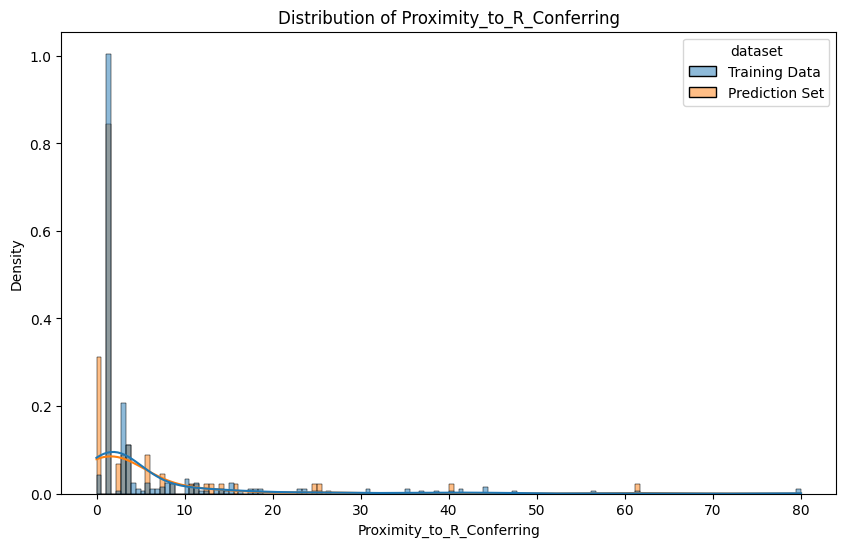

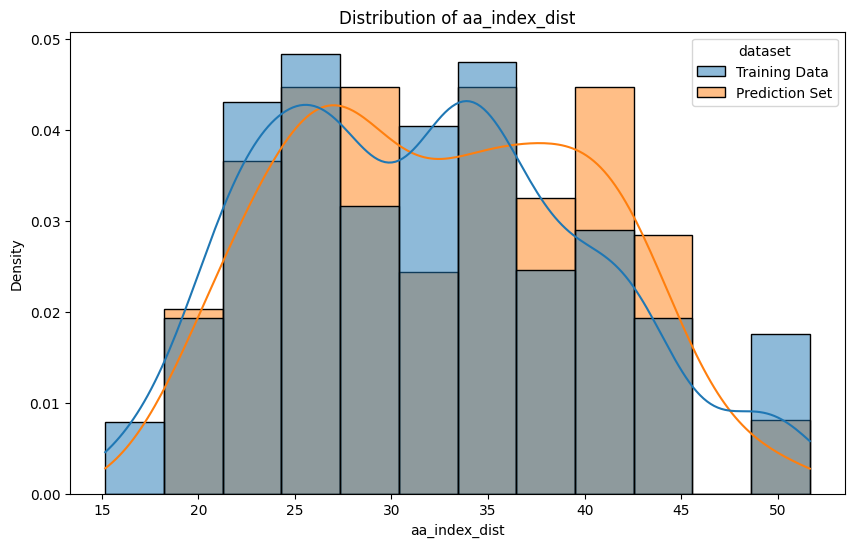

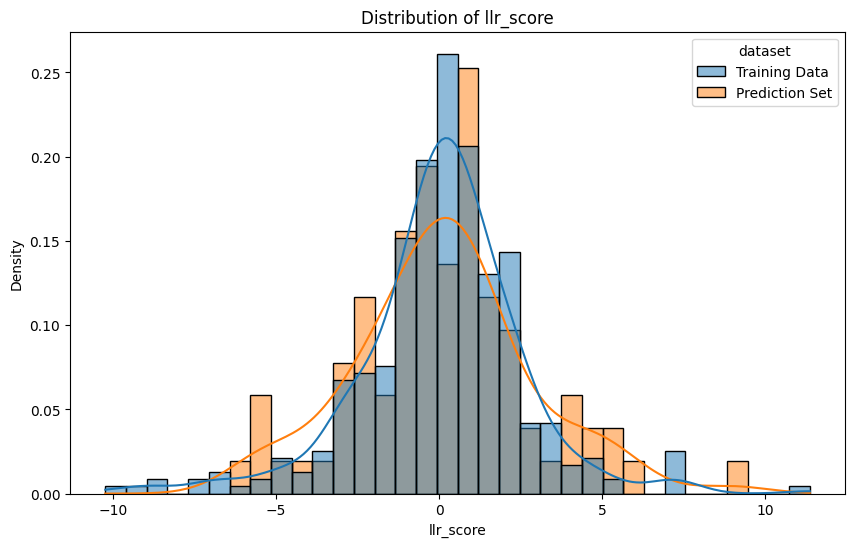

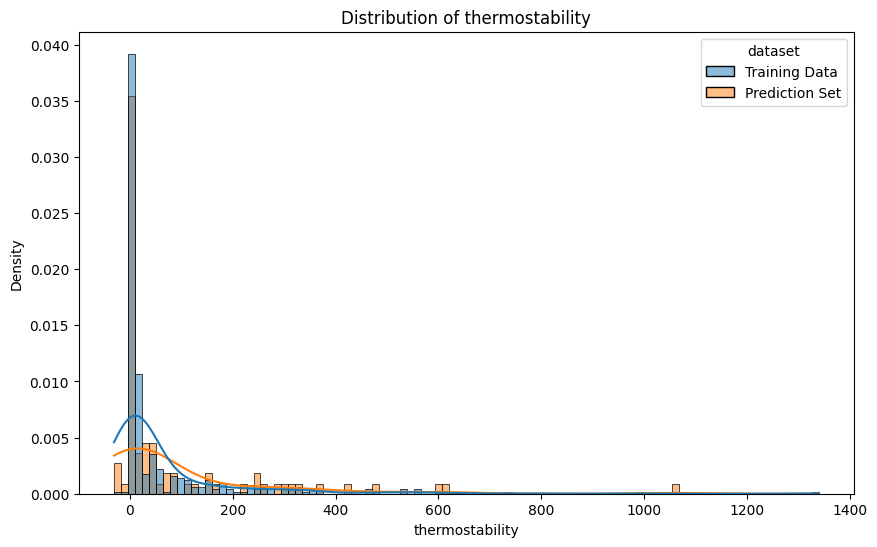

In [122]:
#histograms and KDE
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the datasets with an indicator
label_data['dataset'] = 'Training Data'
category_3_data['dataset'] = 'Prediction Set'

combined_data = pd.concat([label_data, category_3_data], ignore_index=True)

# Plot histograms and KDE plots for each numeric feature
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_data, x=col, hue='dataset', kde=True, stat="density", common_norm=False)
    plt.title(f'Distribution of {col}')
    plt.show()


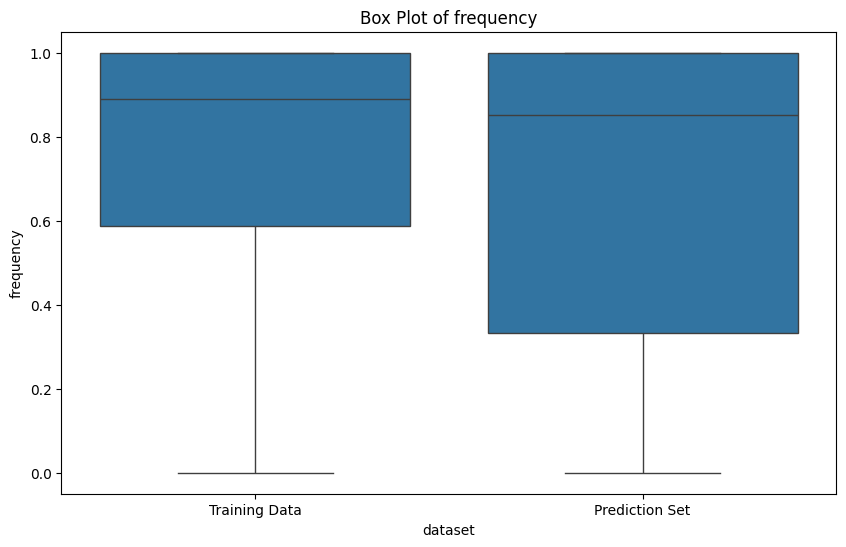

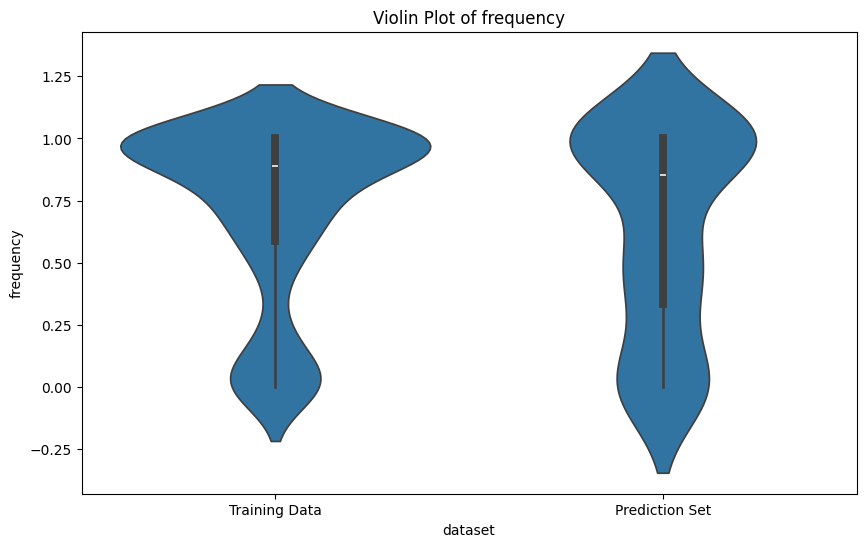

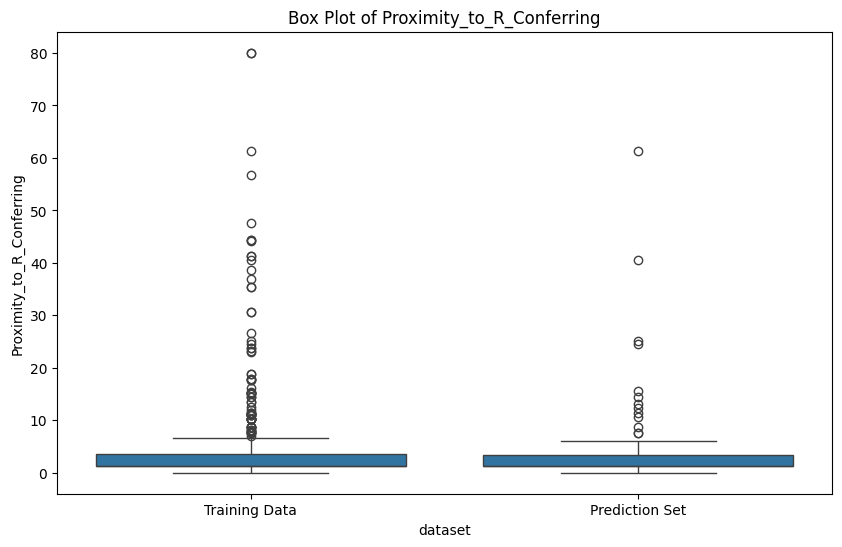

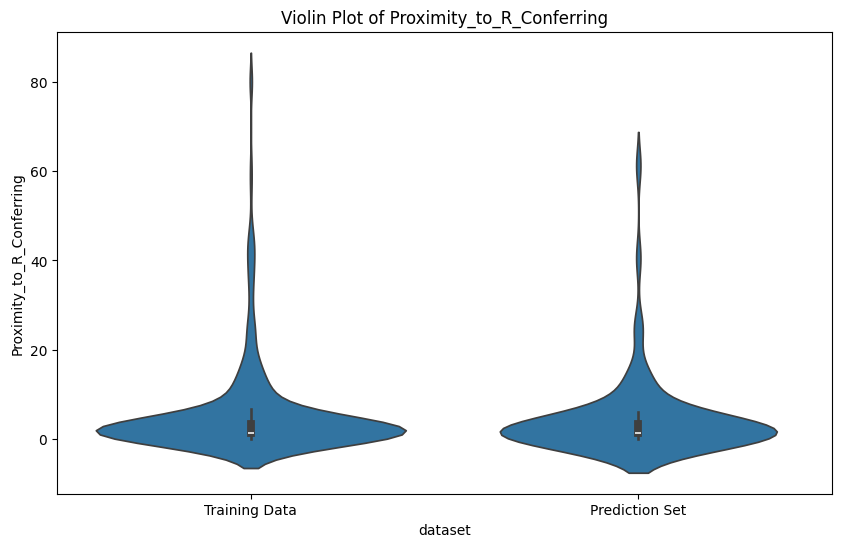

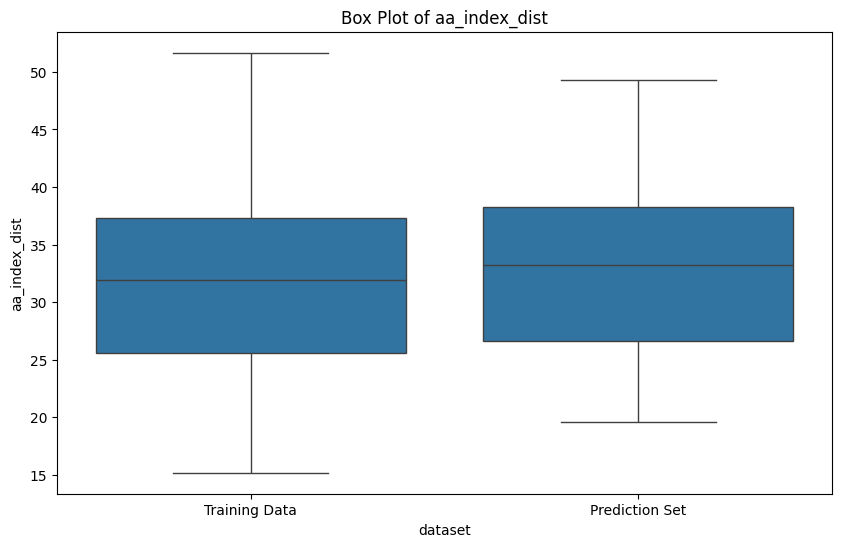

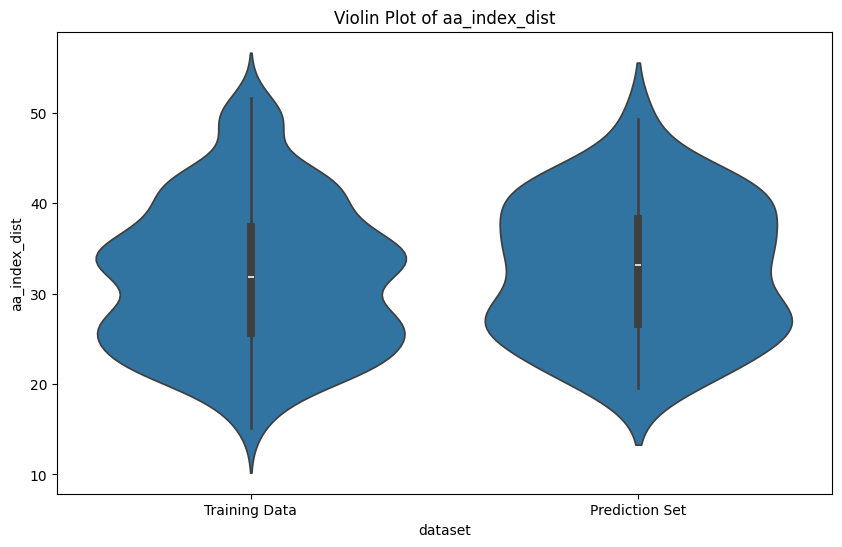

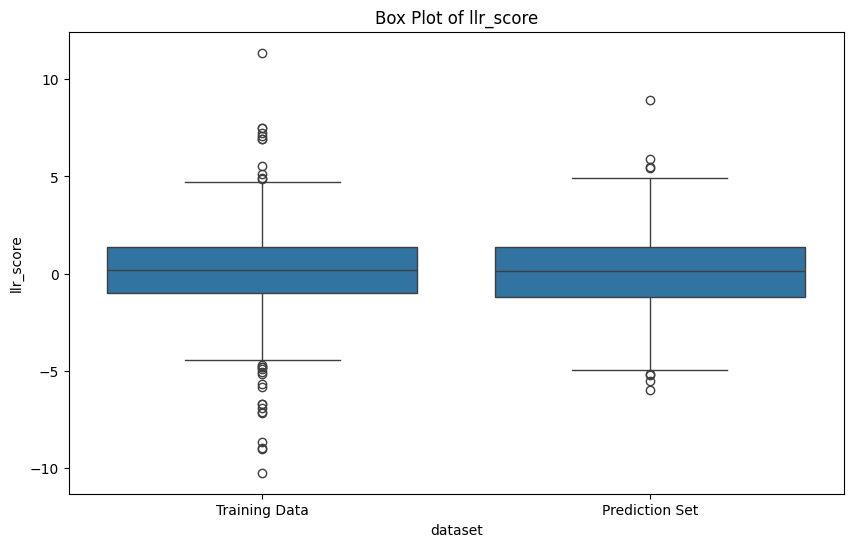

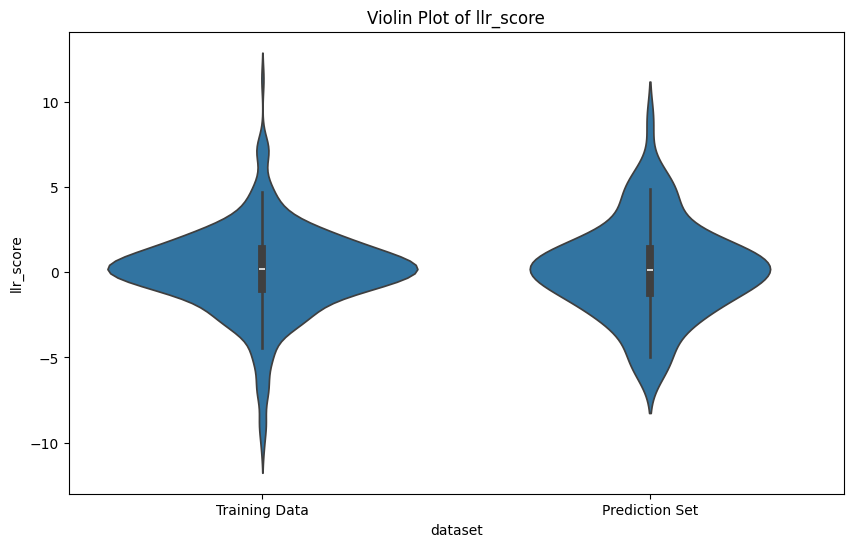

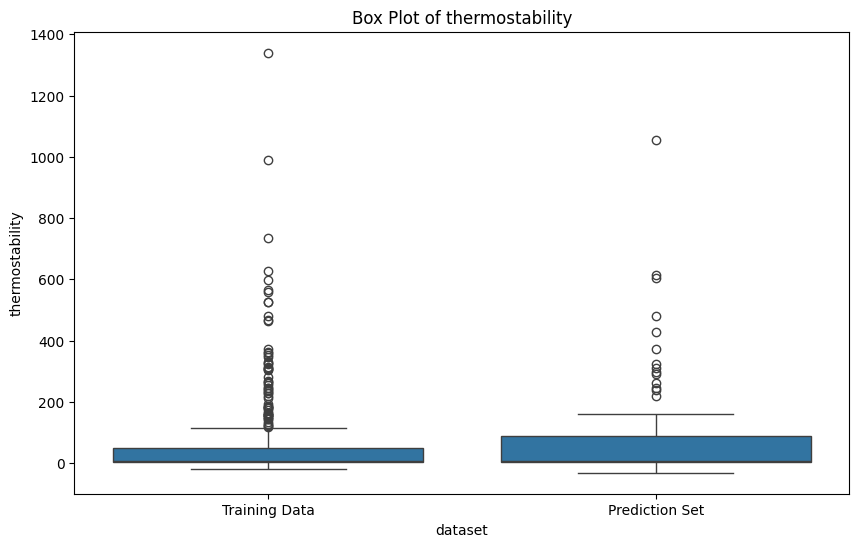

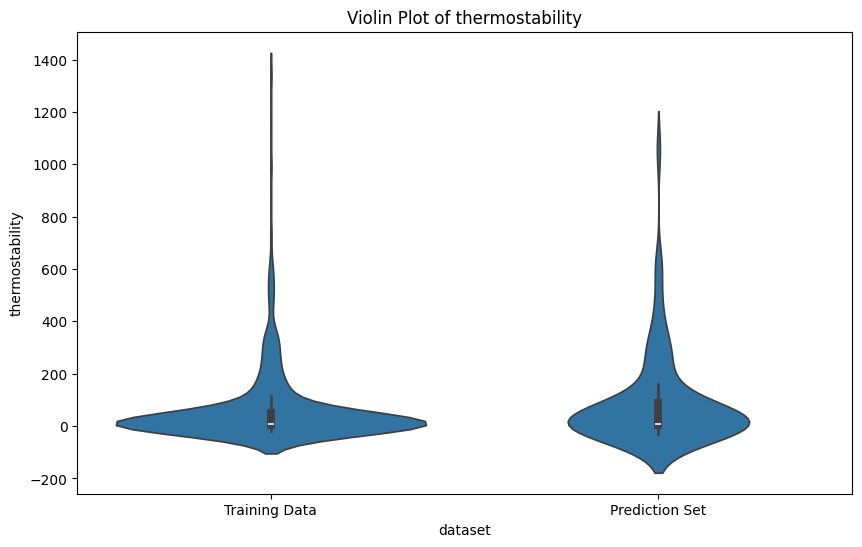

In [57]:
##box_plots and violin plots
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='dataset', y=col, data=combined_data)
    plt.title(f'Box Plot of {col}')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='dataset', y=col, data=combined_data)
    plt.title(f'Violin Plot of {col}')
    plt.show()


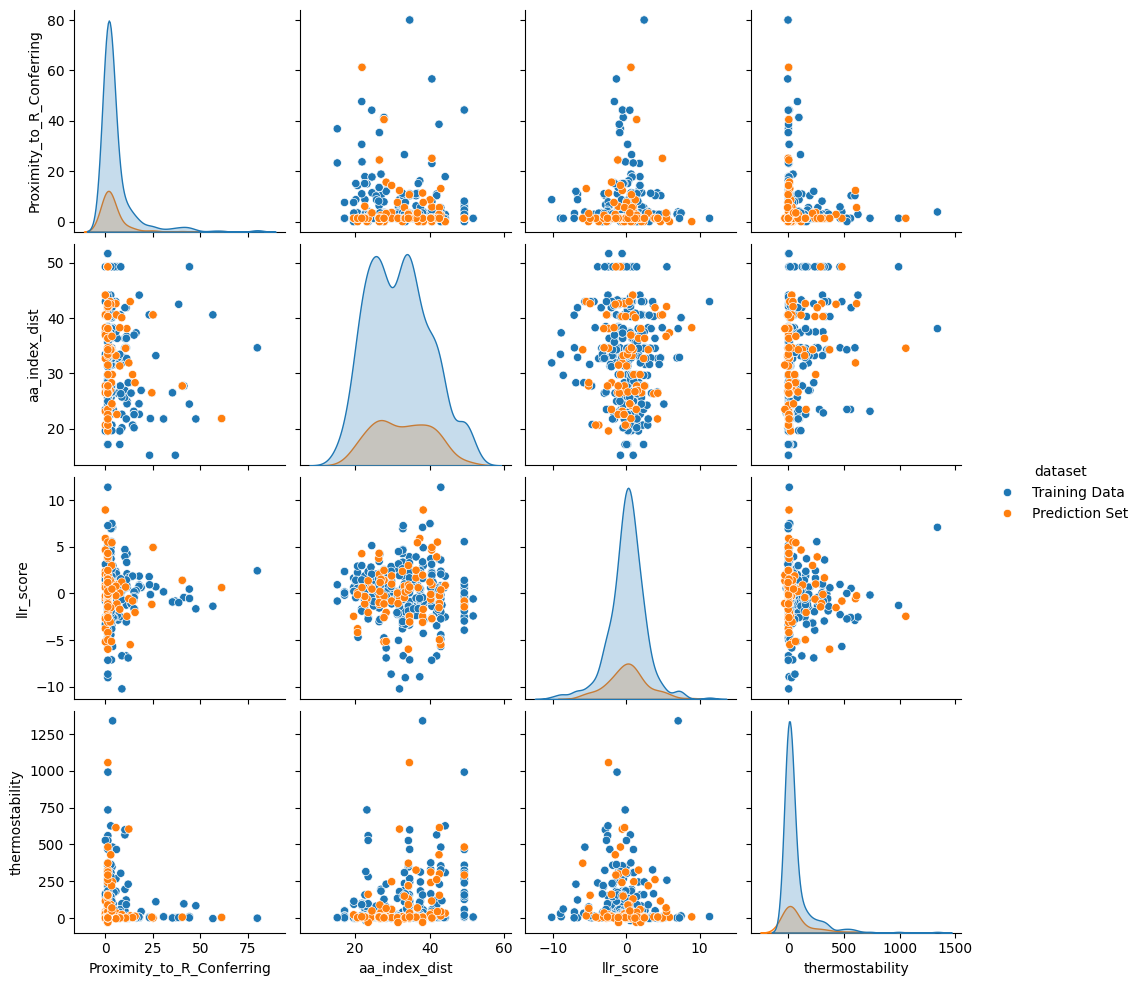

In [123]:
## pair plots
sns.pairplot(combined_data, vars=numeric_columns, hue='dataset', diag_kind='kde')
plt.show()

### stat significance test: check if diff in dist significant

In [124]:
# Kolmogorov-Smirnov Test:This test compares the distributions of two samples.
from scipy.stats import ks_2samp

for col in numeric_columns:
    stat, p_value = ks_2samp(label_data[col], category_3_data[col])
    print(f'Kolmogorov-Smirnov test for {col}: statistic={stat}, p-value={p_value}')


Kolmogorov-Smirnov test for Proximity_to_R_Conferring: statistic=0.20254835941110452, p-value=0.007073691809272222
Kolmogorov-Smirnov test for aa_index_dist: statistic=0.08754208754208755, p-value=0.6496557187988452
Kolmogorov-Smirnov test for llr_score: statistic=0.07532844787746748, p-value=0.8120591301722623
Kolmogorov-Smirnov test for thermostability: statistic=0.11556743909685085, p-value=0.30831239194673216


In [126]:
# Mann-Whitney U Test
# A non-parametric test to compare medians of two independent samples.
from scipy.stats import mannwhitneyu

for col in numeric_columns:
    stat, p_value = mannwhitneyu(label_data[col], category_3_data[col], alternative='two-sided')
    print(f'Mann-Whitney U test for {col}: statistic={stat}, p-value={p_value}')

Mann-Whitney U test for Proximity_to_R_Conferring: statistic=17539.5, p-value=0.025764692509142532
Mann-Whitney U test for aa_index_dist: statistic=14093.5, p-value=0.3262331671048718
Mann-Whitney U test for llr_score: statistic=15271.5, p-value=0.9079918806713565
Mann-Whitney U test for thermostability: statistic=14627.5, p-value=0.6285817028277353


In [127]:
from scipy.stats import ttest_ind

for col in numeric_columns:
    stat, p_value = ttest_ind(label_data[col], category_3_data[col], equal_var=False)
    print(f'T-Test for {col}: statistic={stat}, p-value={p_value}')


T-Test for Proximity_to_R_Conferring: statistic=1.0226850534945073, p-value=0.3083320064314113
T-Test for aa_index_dist: statistic=-0.8514424094858343, p-value=0.39616845856620087
T-Test for llr_score: statistic=-0.23144439753397578, p-value=0.8173953367758741
T-Test for thermostability: statistic=-1.2393732817782235, p-value=0.2180201019869561


In [128]:
label_stats = label_data[numeric_columns].describe().transpose()
category_3_stats = category_3_data[numeric_columns].describe().transpose()

# Combine the statistics
summary_stats = label_stats.join(category_3_stats, lsuffix='_label', rsuffix='_category_3')

display(summary_stats)


,count_label,mean_label,std_label,min_label,25%_label,50%_label,75%_label,max_label,count_category_3,mean_category_3,std_category_3,min_category_3,25%_category_3,50%_category_3,75%_category_3,max_category_3
Proximity_to_R_Conferring,374.0,5.658455,10.534226,0.000000,1.329035,1.340485,3.507375,80.054466,81.0,4.491046,9.028494,0.000000,1.324421,1.336594,3.444930,61.260052
aa_index_dist,374.0,31.783440,8.163219,15.178922,25.616944,31.887645,37.326490,51.659765,81.0,32.584394,7.566126,19.571518,26.619463,33.197953,38.250585,49.271705
llr_score,374.0,0.057982,2.521747,-10.227083,-0.973467,0.185939,1.364001,11.361466,81.0,0.134784,2.746283,-5.981173,-1.184463,0.144248,1.395799,8.924709
thermostability,374.0,64.248229,141.290964,-18.053326,2.950594,8.326051,48.285990,1339.677188,81.0,90.271418,177.164930,-31.056949,2.954118,7.673205,88.078396,1055.820469


### feature importance

In [129]:

importances = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': numeric_columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)


                     feature  importance
0  Proximity_to_R_Conferring    0.473108
2                  llr_score    0.219145
1              aa_index_dist    0.157363
3            thermostability    0.150384


### dimensionality Reduction

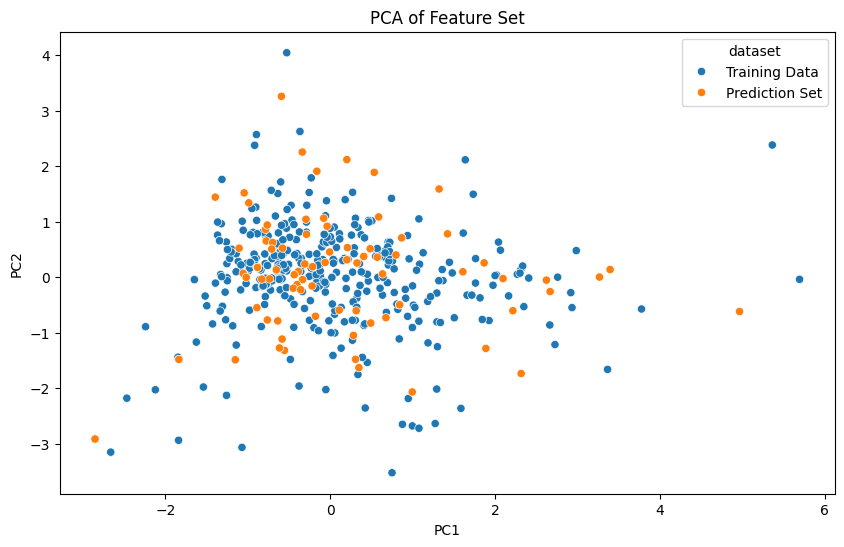

In [130]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Combine the data
combined_features = combined_data[numeric_columns]
combined_features = combined_features.fillna(0)  # Ensure no NaNs

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame with principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['dataset'] = combined_data['dataset'].values

# Plot the PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='dataset', data=pca_df)
plt.title('PCA of Feature Set')
plt.show()


### overlapping histograms

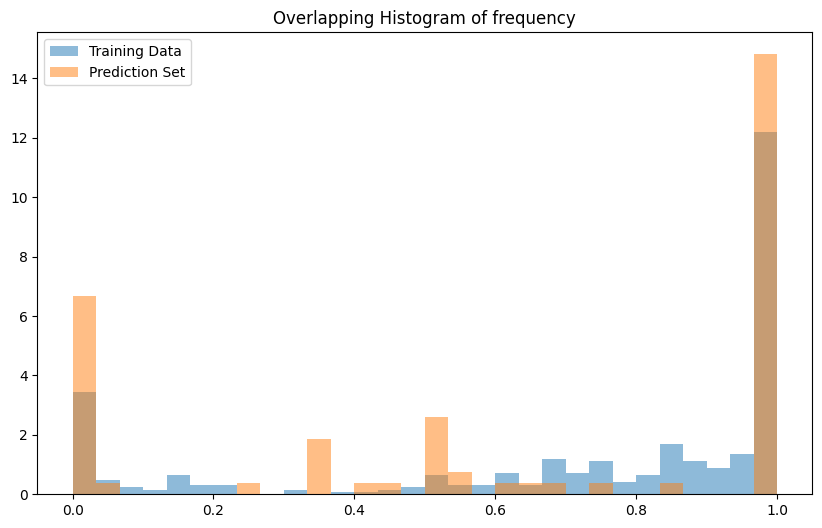

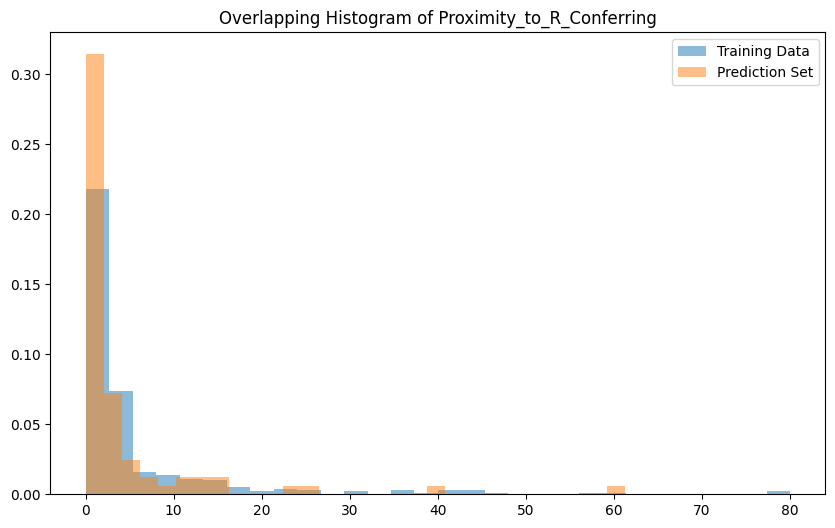

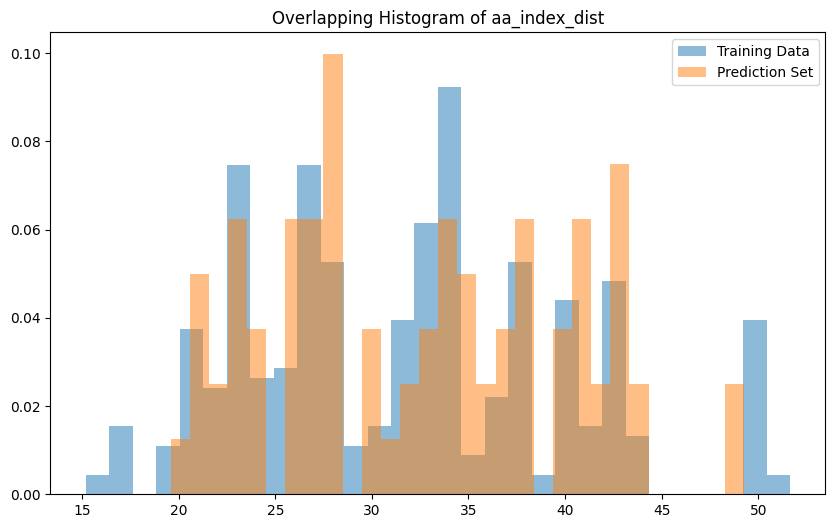

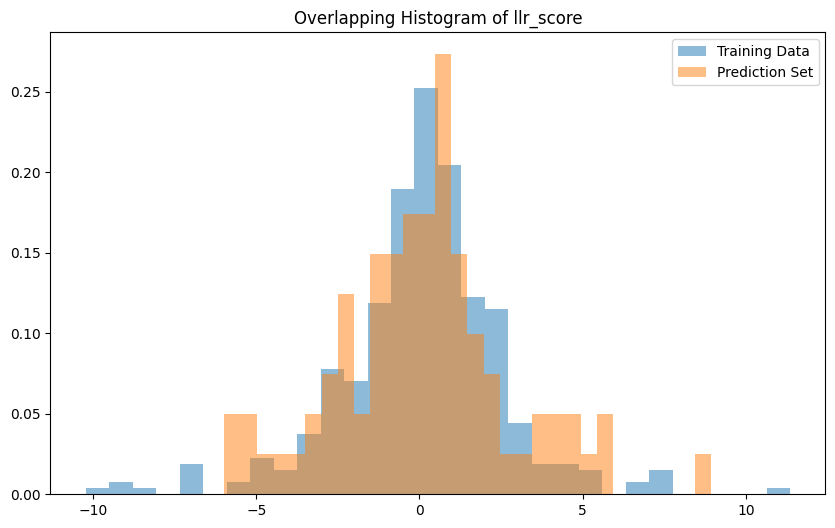

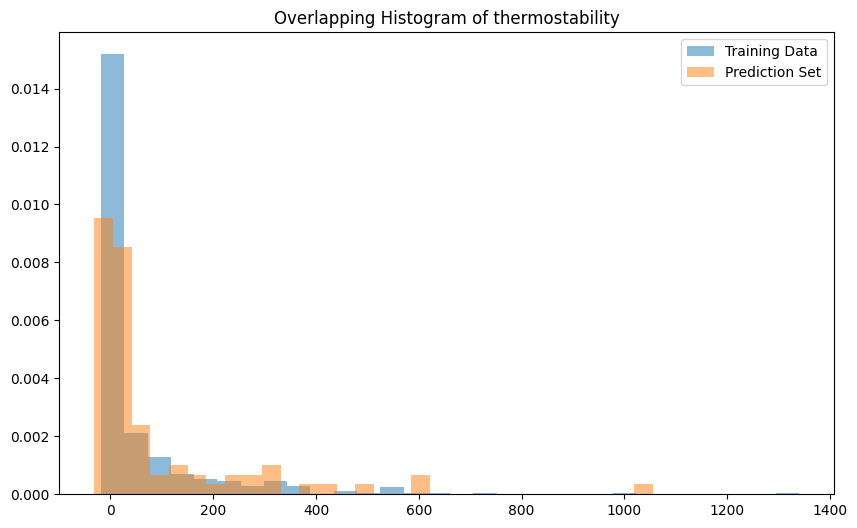

In [65]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    plt.hist(label_data[col], bins=30, alpha=0.5, label='Training Data', density=True)
    plt.hist(category_3_data[col], bins=30, alpha=0.5, label='Prediction Set', density=True)
    plt.title(f'Overlapping Histogram of {col}')
    plt.legend()
    plt.show()


### qq plots

<Figure size 1000x600 with 0 Axes>

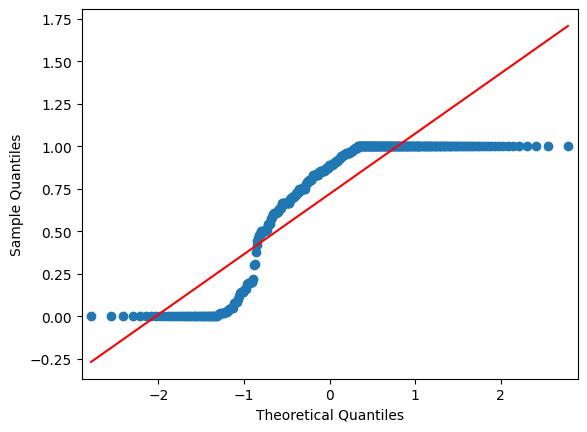

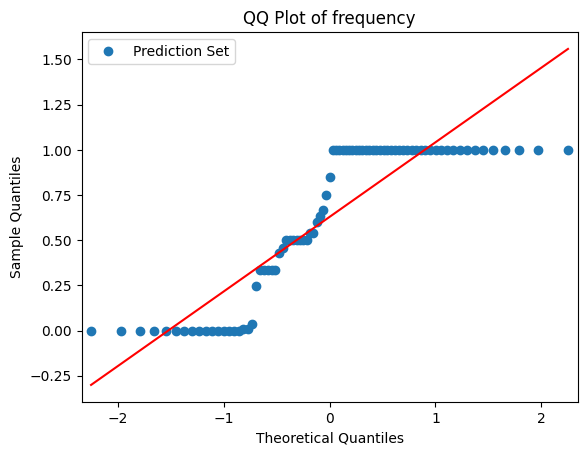

In [66]:
import statsmodels.api as sm

for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sm.qqplot(label_data[col], line='s', label='Training Data')
    sm.qqplot(category_3_data[col], line='s', label='Prediction Set')
    plt.title(f'QQ Plot of {col}')
    plt.legend()
    plt.show()
    break

### corr analysis

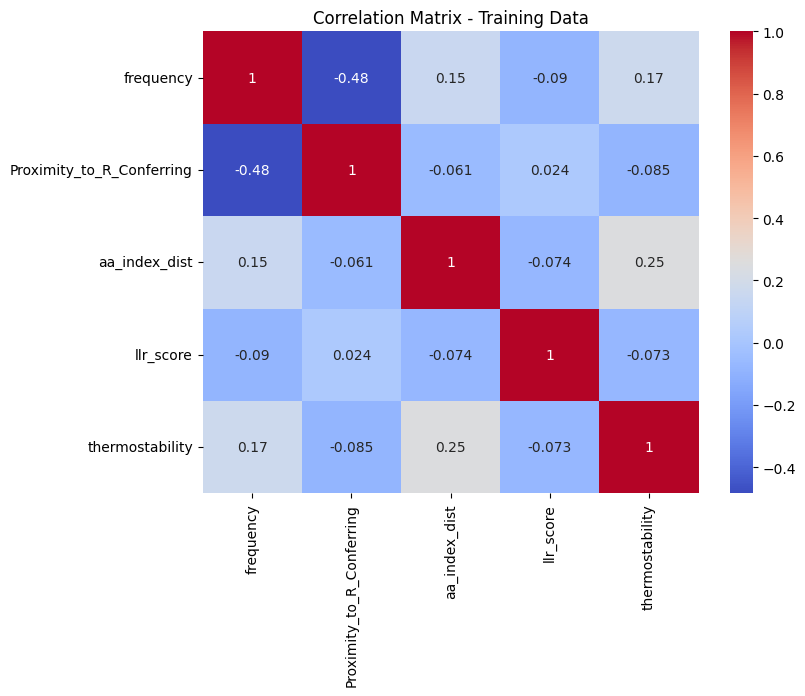

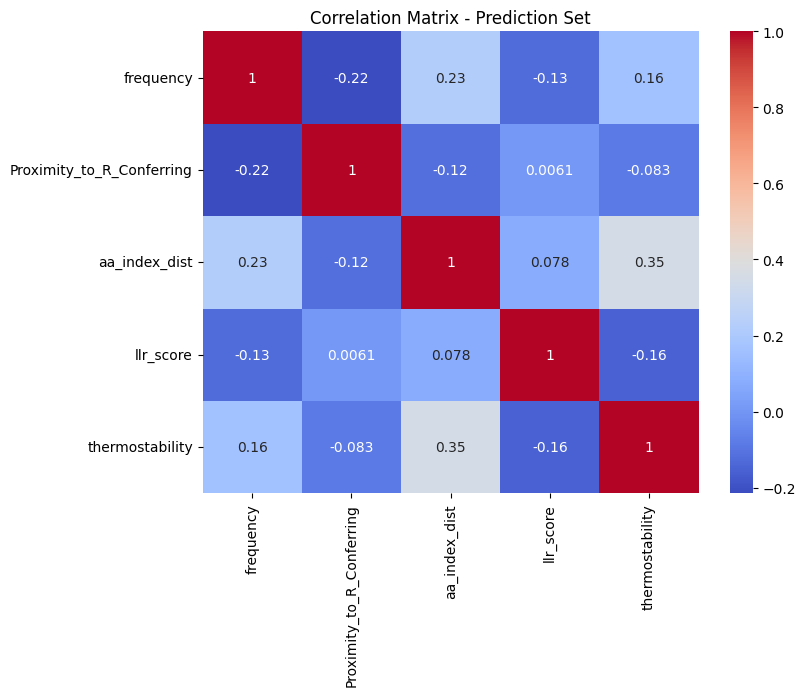

In [67]:
# Compute correlation matrices
corr_label = label_data[numeric_columns].corr()
corr_category_3 = category_3_data[numeric_columns].corr()

# Plot correlation heatmaps
plt.figure(figsize=(8, 6))
sns.heatmap(corr_label, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Training Data')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_category_3, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Prediction Set')
plt.show()


### examine outliers

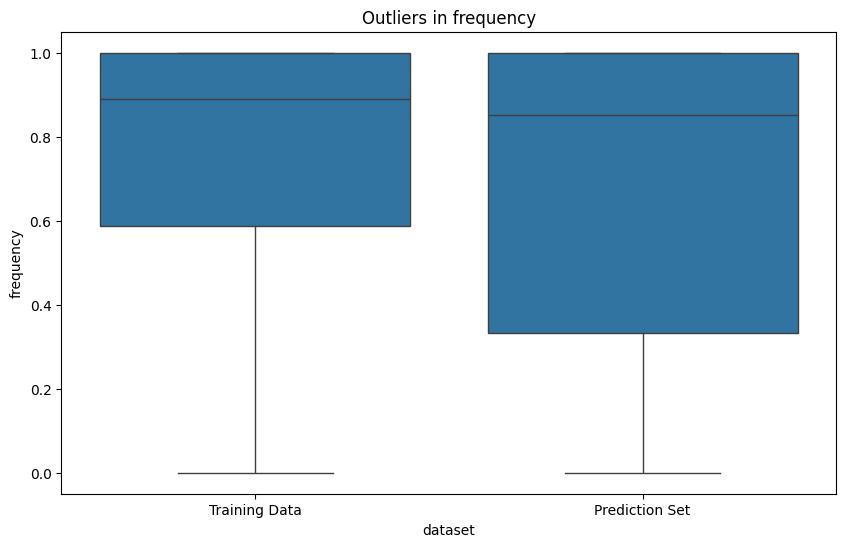

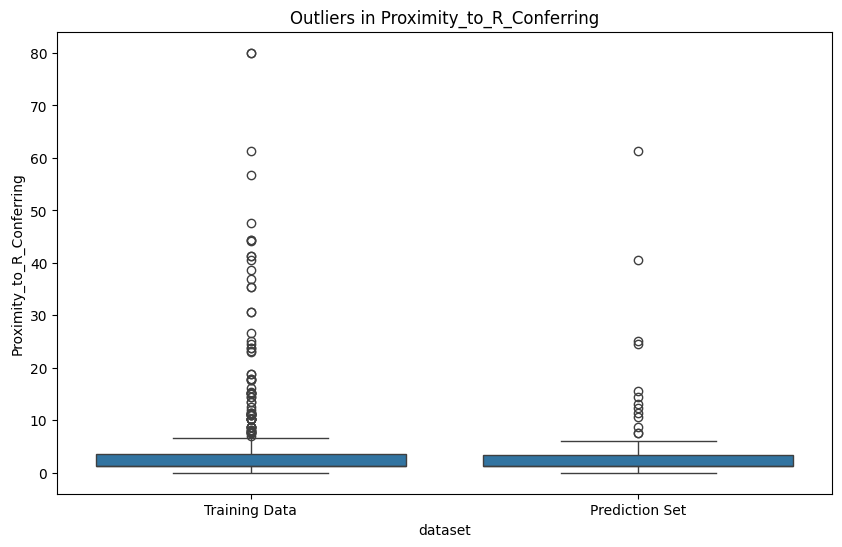

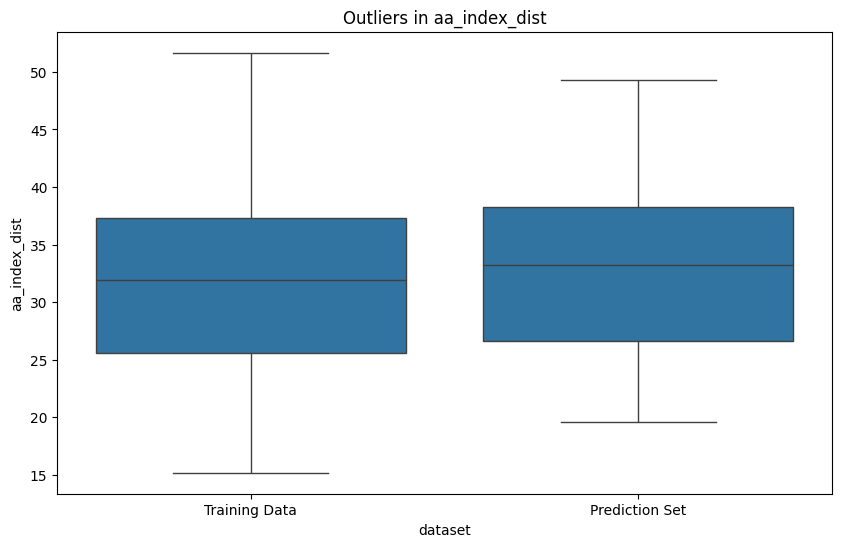

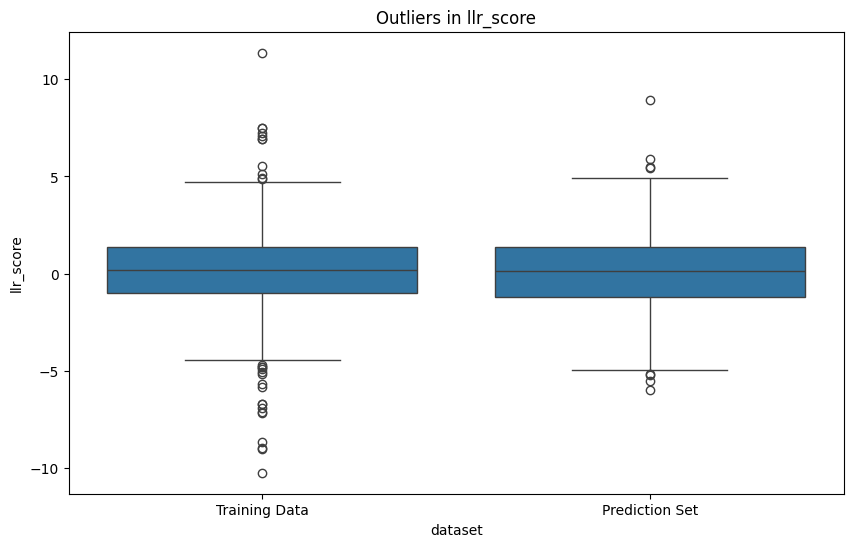

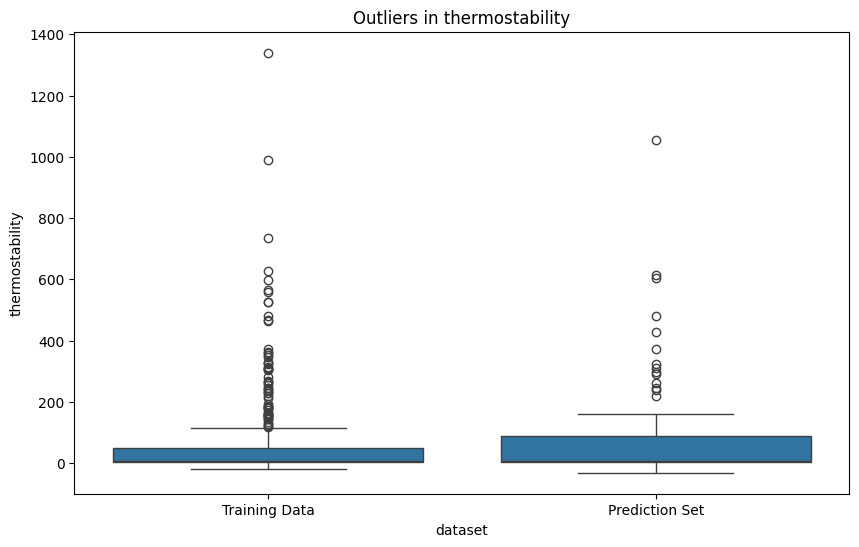

In [68]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='dataset', y=col, data=combined_data)
    plt.title(f'Outliers in {col}')
    plt.show()


### analyze the impact on model performance

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without f

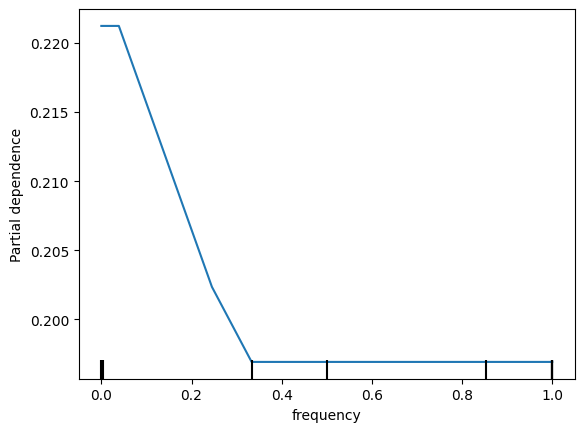

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without f

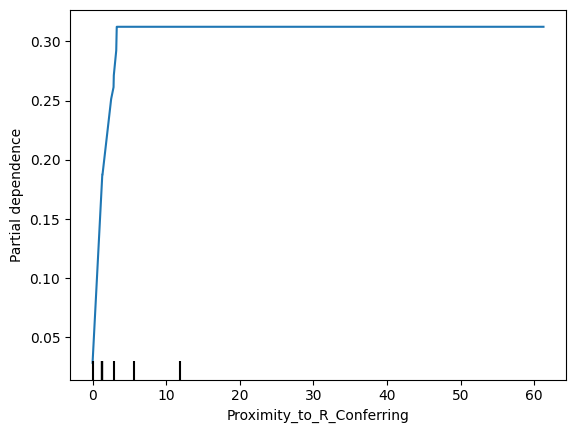

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without f

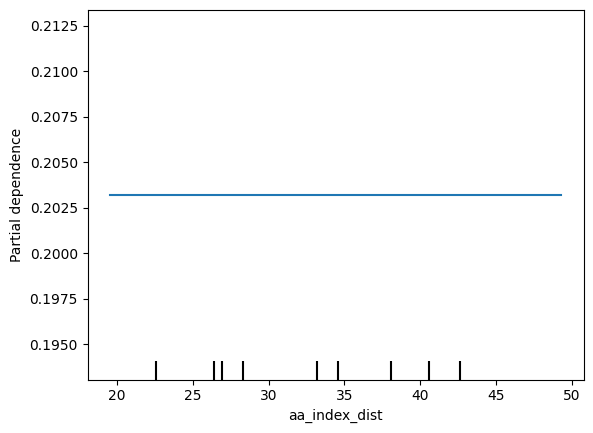

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without f

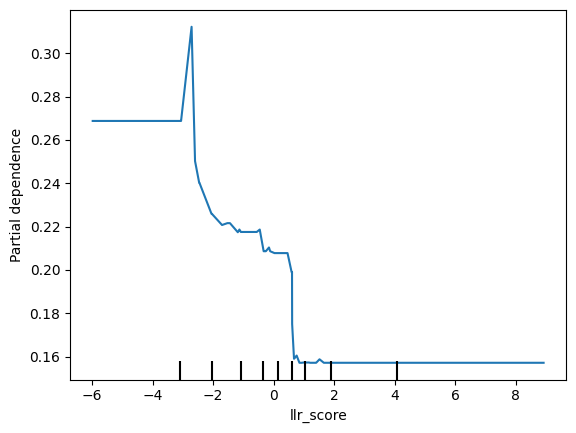

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without f

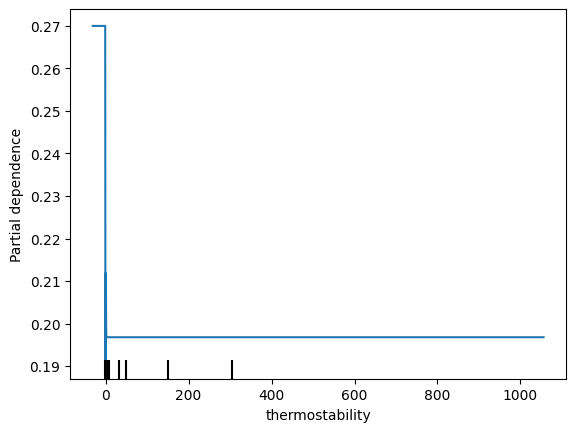

In [69]:
#Partial Dependence Plots: Show the relationship between the target variable and a feature.
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

for feature in numeric_columns:
    disp = PartialDependenceDisplay.from_estimator(rf_classifier, X_category_3, [feature])
    plt.show()


In [70]:
### use shap values

In [71]:
import shap

# Initialize the JS visualization code
shap.initjs()

# Explain predictions using SHAP
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_category_3)

# Visualize the first prediction's explanation
shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_category_3.iloc[0,:])


DimensionError: Length of features is not equal to the length of shap_values!

### Individual Gene with four training classes

In [41]:
# Load the phenotype data
catalog_data = pd.read_csv('./data/derived_features/all_proteins_freq_details_proximity_aaindex_llr.csv')
catalog_data = catalog_data.drop_duplicates()

# List of numeric columns to use as features
numeric_columns = ['frequency', 'Proximity_to_R_Conferring', 'aa_index_dist', 'llr_score']

# Fill NaN values in the features with 0 or any suitable value
catalog_data[numeric_columns] = catalog_data[numeric_columns].fillna(0)

# Convert the target variable to numeric labels
catalog_data['confidence_numeric'] = catalog_data['confidence'].map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 2,
    "4) Not assoc w R - Interim": 4,
    "5) Not assoc w R": 5
})

# List to store performance metrics for each gene
results = []


In [42]:
# Function to predict the confidence categories for entries labeled as "3) Uncertain significance" for a specific gene
def predict_category_3_entries_for_gene(gene_of_interest, rf_classifier):
    # Filter the entries for the specific gene and category 3 ("3) Uncertain significance")
    category_3_data = catalog_data[(catalog_data['gene'] == gene_of_interest) & (catalog_data['confidence'] == "3) Uncertain significance")]
    
    # Calculate the total number of category 3 instances
    total_category_3_instances = len(category_3_data)
    
    if category_3_data.empty:
        print(f"No entries labeled as '3) Uncertain significance' for gene {gene_of_interest}.")
        return {"Total Category 3 Instances": total_category_3_instances}
    
    # Fill NaN values in numeric columns for category 3 data
    category_3_data.loc[:, numeric_columns] = category_3_data[numeric_columns].fillna(0)
    
    # Extract the features for category 3 data
    X_category_3 = category_3_data[numeric_columns]
    
    # Predict the confidence category for the category 3 entries
    category_3_data.loc[:, 'predicted_confidence'] = rf_classifier.predict(X_category_3)
    
    # Count how many instances of category 3 were predicted as category 1, 2, 4, or 5
    prediction_summary = category_3_data['predicted_confidence'].value_counts().to_dict()
    
    # Print the breakdown of predictions
    print(f"Breakdown of predictions for 'Uncertain significance' entries of gene {gene_of_interest}:")
    breakdown_dict = {"Total Category 3 Instances": total_category_3_instances}
    for category, count in prediction_summary.items():
        breakdown_dict[f"Category {int(category)}"] = count
        print(f"Category {int(category)}: {count} instances")

    # Update the original catalog_data DataFrame with predicted categories for category 3 for this gene
    catalog_data.loc[(catalog_data['gene'] == gene_of_interest) & (catalog_data['confidence'] == "3) Uncertain significance"), 'predicted_confidence'] = category_3_data['predicted_confidence']
    
    # Return the breakdown as part of the gene summary
    return breakdown_dict


In [ ]:
# List to store the final summary results for each gene
gene_summary = []

# Function to train and evaluate the model for a specific gene with checks and print details
def run_rf_for_gene(gene_of_interest):
    # Filter the DataFrame for the specific gene and remove "Uncertain significance" entries
    gene_data = catalog_data[(catalog_data['gene'] == gene_of_interest) & (catalog_data['confidence'] != "3) Uncertain significance")]
    
    # Check if there's sufficient data for this gene
    if gene_data.empty:
        print(f"No data available for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Print dataset details for the gene
    total_samples = len(gene_data)
    classes_present = gene_data['confidence_numeric'].unique()
    print(f"\nGene: {gene_of_interest}")
    print(f"Total samples: {total_samples}")
    print(f"Classes present: {classes_present}")
    
    if total_samples < 5:
        print(f"Warning: Insufficient data for training the model for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Extract features and target
    X_gene = gene_data[numeric_columns]
    y_gene = gene_data['confidence_numeric']

    # Get the value counts of each class in the gene data
    class_counts = y_gene.value_counts().to_dict()
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled_gene = scaler.fit_transform(X_gene)
    
    # Split the data into training and testing sets
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled_gene, y_gene, test_size=0.3, random_state=42)
    
    # Handle the case where training data is too small
    if len(y_train_split) == 0:
        print(f"Not enough data to train for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Train the random forest classifier
    # rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=4, min_samples_split=2, random_state=42)
    rf_classifier.fit(X_train_split, y_train_split)
    
    # Make predictions on the test set
    y_pred_split = rf_classifier.predict(X_test_split)
    
    # Save the predictions for this gene
    gene_predictions = pd.DataFrame({
        'gene': gene_of_interest,
        'true_label': y_test_split,
        'predicted_label': y_pred_split
    })
#     global prediction_results
#     prediction_results = pd.concat([prediction_results, gene_predictions], ignore_index=True)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test_split, y_pred_split)
    report = classification_report(y_test_split, y_pred_split, output_dict=True)
    print(f"Results for {gene_of_interest}: Accuracy = {accuracy:.4f}")
    
    # Function to handle missing classes by assigning NaN
    def get_metric(report, cls, metric):
        return report[str(cls)][metric] if str(cls) in report else np.nan
    
    feature_importances = rf_classifier.feature_importances_
    indices = np.argsort(feature_importances)[::-1]
    top_n = 4 # Specify how many top features you want to track
    top_features = [(numeric_columns[i], feature_importances[i]) for i in indices[:top_n]]

    # Include precision, recall, and F1-score for each category (1, 2, 4, 5)
    gene_result = {
        'gene': gene_of_interest,
        'train_data': gene_data.shape,
        'classes_present': classes_present,
        'class_counts': class_counts,
        'accuracy': accuracy,
        'precision_1': get_metric(report, 1.0, 'precision'),
        'recall_1': get_metric(report, 1.0, 'recall'),
        'f1_score_1': get_metric(report, 1.0, 'f1-score'),
        'precision_2': get_metric(report, 2.0, 'precision'),
        'recall_2': get_metric(report, 2.0, 'recall'),
        'f1_score_2': get_metric(report, 2.0, 'f1-score'),
        'precision_4': get_metric(report, 4.0, 'precision'),
        'recall_4': get_metric(report, 4.0, 'recall'),
        'f1_score_4': get_metric(report, 4.0, 'f1-score'),
        'precision_5': get_metric(report, 5.0, 'precision'),
        'recall_5': get_metric(report, 5.0, 'recall'),
        'f1_score_5': get_metric(report, 5.0, 'f1-score'),
        'feature_importances': feature_importances.tolist(),  # Add all feature importances as a list
        'top_features': top_features
    }
    
    # After training the RF model, predict for category 3 entries for this gene
    breakdown = predict_category_3_entries_for_gene(gene_of_interest, rf_classifier)
    
    # Add the breakdown of predictions for category 3 entries
    gene_result.update(breakdown)
    
    # Append the result to the gene_summary list
    gene_summary.append(gene_result)





# Run for multiple genes and save results to a DataFrame
unique_genes = catalog_data['gene'].unique()
for gene in unique_genes:
    run_rf_for_gene(gene)

# Convert the gene summary into a DataFrame
gene_summary_df = pd.DataFrame(gene_summary)

# Save the gene summary to a CSV file
gene_summary_df.to_csv('gene_summary_with_metrics.csv', index=False)

print("Gene summary saved to 'gene_summary_with_metrics.csv'.")
# Save the prediction results to a CSV file
# prediction_results.to_csv('rf_gene_predictions.csv', index=False)

### for collapsed target class of two

In [52]:
# List to store the final summary results for each gene
gene_summary = []
# Function to train and evaluate the model for a specific gene with checks and print details
def run_rf_for_gene_collapsed(gene_of_interest):
    # Filter the DataFrame for the specific gene and remove "Uncertain significance" entries
    gene_data = catalog_data[(catalog_data['gene'] == gene_of_interest) & (catalog_data['confidence'] != "3) Uncertain significance")]
    
    # Check if there's sufficient data for this gene
    if gene_data.empty:
        print(f"No data available for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Print dataset details for the gene
    total_samples = len(gene_data)
    print(f"\nGene: {gene_of_interest}")
    print(f"Total samples: {total_samples}")
    
    if total_samples < 5:
        print(f"Warning: Insufficient data for training the model for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Extract features and target
    X_gene = gene_data[numeric_columns]
    
    # **Updated target mapping**
    y_gene = gene_data['confidence'].map({
        "1) Assoc w R": 1,
        "2) Assoc w R - Interim": 1,  # Combine this with 1
        "4) Not assoc w R - Interim": 2,  # Combine this with 2
        "5) Not assoc w R": 2  # Combine this with 2
    })
    classes_present = gene_data['confidence_numeric'].unique()
    # Get the value counts of each class in the gene data
    class_counts = y_gene.value_counts().to_dict()
    # Scale the features
    scaler = StandardScaler()
    X_scaled_gene = scaler.fit_transform(X_gene)
    
    # Split the data into training and testing sets
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled_gene, y_gene, test_size=0.3, random_state=42)
    
    # Handle the case where training data is too small
    if len(y_train_split) == 0:
        print(f"Not enough data to train for gene {gene_of_interest}. Skipping this gene.")
        return
    
    # Train the random forest classifier
    rf_classifier = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=4, min_samples_split=2, random_state=42)
    rf_classifier.fit(X_train_split, y_train_split)
    
    # Make predictions on the test set
    y_pred_split = rf_classifier.predict(X_test_split)
    
    # Save the predictions for this gene
    gene_predictions = pd.DataFrame({
        'gene': gene_of_interest,
        'true_label': y_test_split,
        'predicted_label': y_pred_split
    })
    # global prediction_results
    # prediction_results = pd.concat([prediction_results, gene_predictions], ignore_index=True)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test_split, y_pred_split)
    report = classification_report(y_test_split, y_pred_split, output_dict=True)
    print(f"Results for {gene_of_interest}: Accuracy = {accuracy:.4f}")
    
    # Function to handle missing classes by assigning NaN
    def get_metric(report, cls, metric):
        return report[str(cls)][metric] if str(cls) in report else np.nan
    feature_importances = rf_classifier.feature_importances_
    indices = np.argsort(feature_importances)[::-1]
    top_n = 4 # Specify how many top features you want to track
    top_features = [(numeric_columns[i], feature_importances[i]) for i in indices[:top_n]]


    # Include precision, recall, and F1-score for each combined category (1, 2)
    gene_result = {
        'gene': gene_of_interest,
        'train_data': gene_data.shape,
        'classes_present': classes_present,
        'class_counts': class_counts,
        'accuracy': accuracy,
        'precision_1': get_metric(report, 1, 'precision'),
        'recall_1': get_metric(report, 1, 'recall'),
        'f1_score_1': get_metric(report, 1, 'f1-score'),
        'precision_2': get_metric(report, 2, 'precision'),
        'recall_2': get_metric(report, 2, 'recall'),
        'f1_score_2': get_metric(report, 2, 'f1-score'),
        'feature_importances': feature_importances.tolist(),  # Add all feature importances as a list
        'top_features': top_features
    }
    
    # After training the RF model, predict for category 3 entries for this gene
    breakdown = predict_category_3_entries_for_gene(gene_of_interest, rf_classifier)
    
    # Add the breakdown of predictions for category 3 entries
    gene_result.update(breakdown)
    
    # Append the result to the gene_summary list
    gene_summary.append(gene_result)


# Run for multiple genes and save results to a DataFrame
unique_genes = catalog_data['gene'].unique()
for gene in unique_genes:
    run_rf_for_gene_collapsed(gene)

# Convert the gene summary into a DataFrame
gene_summary_df = pd.DataFrame(gene_summary)

# Save the gene summary to a CSV file
gene_summary_df.to_csv('gene_summary_with_metrics_collapsed.csv', index=False)

print("Gene summary saved to 'gene_summary_with_metrics_collapsed.csv'.")
# # Save the prediction results to a CSV file
# prediction_results.to_csv('rf_gene_predictions_collapsed.csv', index=False)


Gene: rpoB
Total samples: 109
Results for rpoB: Accuracy = 1.0000


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_c

Breakdown of predictions for 'Uncertain significance' entries of gene rpoB:
Category 1: 686 instances

Gene: inhA
Total samples: 3

Gene: katG
Total samples: 7
Results for katG: Accuracy = 0.6667
Breakdown of predictions for 'Uncertain significance' entries of gene katG:
Category 1: 832 instances

Gene: embB
Total samples: 21
Results for embB: Accuracy = 0.5714
Breakdown of predictions for 'Uncertain significance' entries of gene embB:
Category 1: 763 instances

Gene: pncA
Total samples: 217
Results for pncA: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene pncA:
Category 1: 147 instances

Gene: gyrA
Total samples: 39


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Results for gyrA: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene gyrA:
Category 1: 797 instances

Gene: rpsL
Total samples: 4

Gene: gid
Total samples: 12
Results for gid: Accuracy = 0.7500
Breakdown of predictions for 'Uncertain significance' entries of gene gid:
Category 1: 498 instances

Gene: ethA
Total samples: 9


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_c

Results for ethA: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene ethA:
Category 1: 558 instances

Gene: atpE
Total samples: 6
Results for atpE: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene atpE:
Category 1: 9 instances

Gene: ddn
Total samples: 1

Gene: Rv0678
Total samples: 16


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Results for Rv0678: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene Rv0678:
Category 1: 274 instances
No data available for gene pepQ. Skipping this gene.

Gene: rplC
Total samples: 1

Gene: tlyA
Total samples: 2

Gene: gyrB
Total samples: 24
Results for gyrB: Accuracy = 1.0000
Breakdown of predictions for 'Uncertain significance' entries of gene gyrB:
Category 1: 554 instances

Gene: fgd1
Total samples: 2
Gene summary saved to 'gene_summary_with_metrics_collapsed.csv'.


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
rpoB_data=pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/rpob_thermostability.csv')
pncA_data=pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/pncA_thermostability.csv')

In [ ]:
# Concatenate the two DataFrames
combined_data = pd.concat([rpoB_data, pncA_data], axis=0, ignore_index=True)

In [ ]:
combined_data =combined_data.drop_duplicates()
print(combined_data.shape)
combined_data['confidence'].value_counts()

In [ ]:
# Filter out category 3 entries
train_data = combined_data[combined_data['confidence'] != "3) Uncertain significance"]

In [ ]:

# List of numeric columns to use as features
numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

# Fill NaN values in the features with 0 or any suitable value
train_data[numeric_columns] = train_data[numeric_columns].fillna(0)

In [ ]:
# Extract the feature matrix and target vector
X_train = train_data[numeric_columns]
y_train = train_data['confidence']
print(X_train.shape, y_train.shape)

In [ ]:
# Convert the target variable to numeric labels
y_train = y_train.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 2,
    "4) Not assoc w R - Interim": 4,
    "5) Not assoc w R": 5
})


In [ ]:
y_train.value_counts()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_train, test_size=0.3, random_state=42)
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))

In [ ]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

# This approach ensures you are accessing the correct column for each class

In [ ]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =combined_data[combined_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
combined_data.loc[combined_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

In [ ]:
combined_data['predicted_confidence'].value_counts()

## weighted sampling

In [69]:
import pandas as pd
combined_data=catalog_data
# Calculate the frequency of each class in the 'confidence' column
confidence_counts = combined_data['confidence'].value_counts()

# Calculate class weights (inversely proportional to frequency)
class_weights = confidence_counts.sum() / confidence_counts
print("Class Weights:\n", class_weights)

# Filter out the '3) Uncertain significance' class
filtered_data = combined_data[combined_data['confidence'] != '3) Uncertain significance']

# Merge the weights back into the filtered DataFrame based on 'confidence' class
filtered_data['weights'] = filtered_data['confidence'].map(class_weights)

# Perform weighted sampling using pandas' sample function
resampled_df = filtered_data.sample(n=len(filtered_data),
                                    replace=True,                         # Sample with replacement
                                    weights=filtered_data['weights'],     # Use calculated weights
                                    random_state=42)                      # Set a seed for reproducibility

# Check the distribution after resampling
print("Resampled confidence distribution:\n", resampled_df['confidence'].value_counts())


Class Weights:
 confidence
3) Uncertain significance       1.082997
2) Assoc w R - Interim         27.431111
1) Assoc w R                   33.182796
5) Not assoc w R              150.536585
4) Not assoc w R - Interim    293.904762
Name: count, dtype: float64
Resampled confidence distribution:
 confidence
2) Assoc w R - Interim        126
5) Not assoc w R              124
4) Not assoc w R - Interim    114
1) Assoc w R                  109
Name: count, dtype: int64


/tmp/ipykernel_54521/2276840899.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['weights'] = filtered_data['confidence'].map(class_weights)


In [70]:
# Filter out category 3 entries
train_data = resampled_df[resampled_df['confidence'] != "3) Uncertain significance"]

# List of numeric columns to use as features
numeric_columns = ['frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score']

# Fill NaN values in the features with 0 or any suitable value
train_data[numeric_columns] = train_data[numeric_columns].fillna(0)

# Extract the feature matrix and target vector
X_train = train_data[numeric_columns]
y_train = train_data['confidence']
print(X_train.shape, y_train.shape)

(473, 4) (473,)


In [71]:
# Convert the target variable to numeric labels
y_train = y_train.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 2,
    "5) Not assoc w R": 2
})


In [72]:
y_train.value_counts()

confidence
2    238
1    235
Name: count, dtype: int64

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_train, test_size=0.3, random_state=42)
# Train the random forest classifier
# rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=4, min_samples_split=2, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))

Confusion Matrix:
[[59  5]
 [ 1 77]]

Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.92      0.95        64
           2       0.94      0.99      0.96        78

    accuracy                           0.96       142
   macro avg       0.96      0.95      0.96       142
weighted avg       0.96      0.96      0.96       142


Accuracy Score:
0.9577464788732394


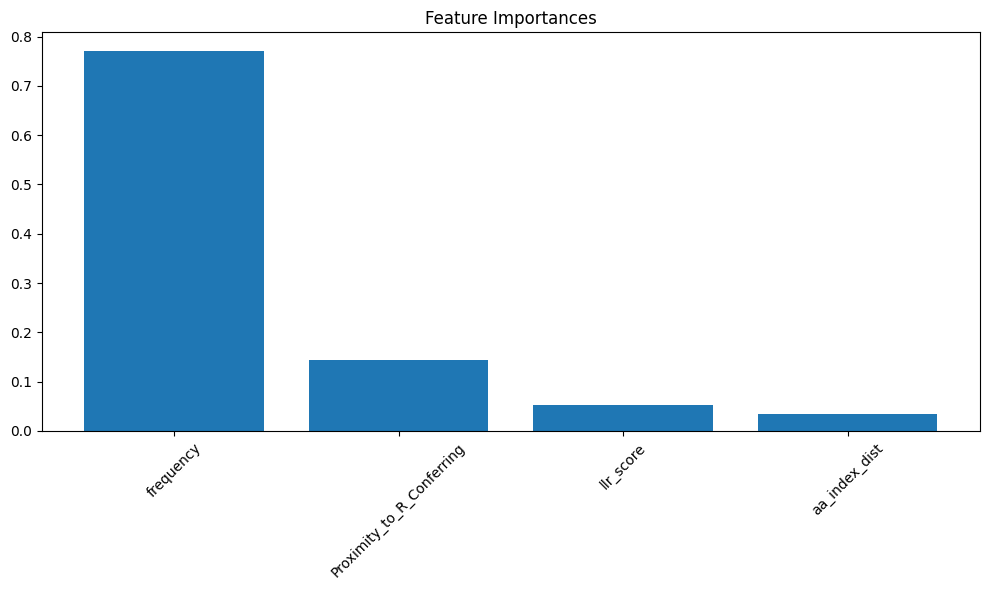

In [81]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

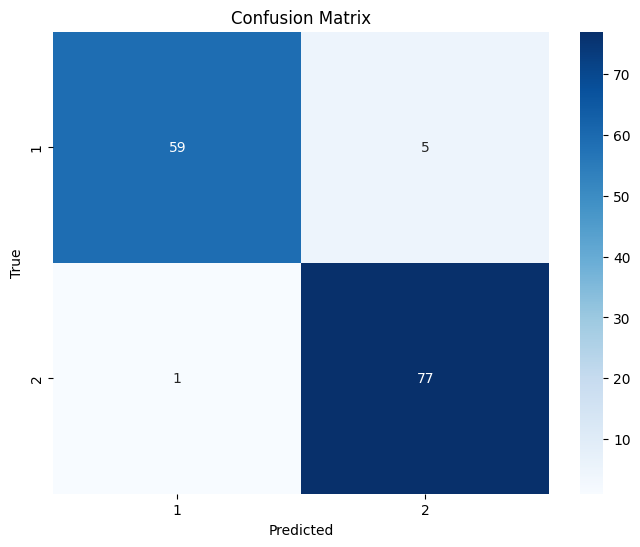

In [82]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [76]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

# This approach ensures you are accessing the correct column for each class

Unique classes: [1, 2]
Number of prediction columns in y_prob_split: 2
1 0.9957932692307693
2 0.9957932692307693


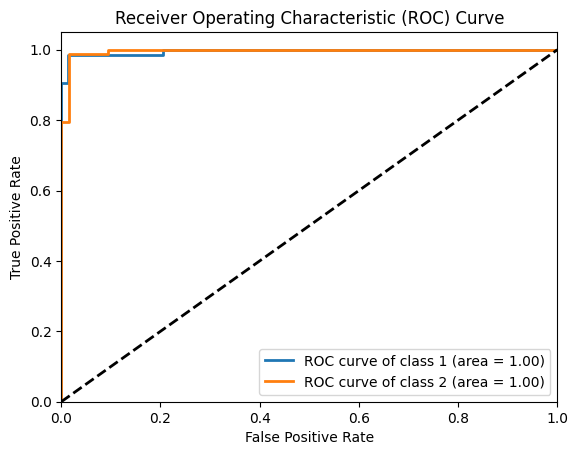

In [83]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [84]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =combined_data[combined_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
combined_data.loc[combined_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

/tmp/ipykernel_54521/1694680787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_54521/1694680787.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data['predicted_confidence'] = rf_classifier.pred

In [85]:
combined_data['predicted_confidence'].value_counts()

predicted_confidence
2.0    2946
1.0    2753
Name: count, dtype: int64